In [1]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import classification_report
import statsmodels.api as sm
import sys
import shap
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve, binary_entropy, matplotlib_to_plotly, interactive_colored_mapbox
import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'
file5 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Peloponnese\GR_Peloponnese_WNV_Dataset_OP_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)
dataset5 = read_data(file5)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset5.head()

dataset = pd.concat([dataset1, 
                     dataset2, 
                     dataset3, 
                     dataset4, 
                     dataset5,
                     ])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(4200, 112)


In [2]:
dataset

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.000000,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.000000,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.000000,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972

In [3]:
len(dataset.NUTS3_ID.unique())

25

In [4]:
dataset = encode_cyclical(dataset, 'month', 12)

In [5]:
dataset.cases.sum()

1768

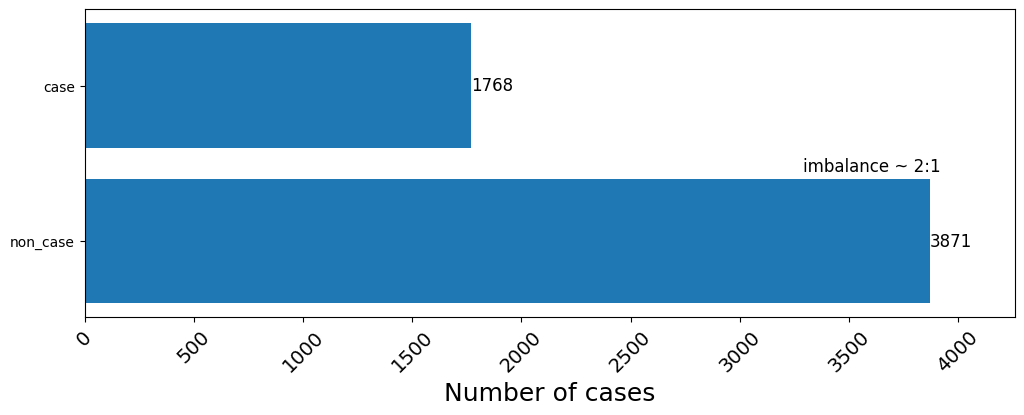

In [6]:
plot_imbalance(dataset, target_column='cases')

In [7]:
dataset = dataset.query('month >= 5 & month <= 10 & year <= 2021')
dataset.reset_index(drop=True, inplace=True)

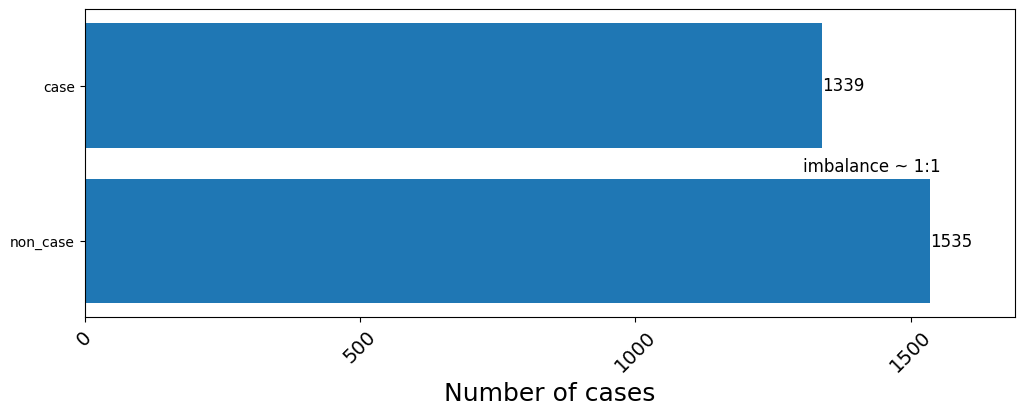

In [8]:
plot_imbalance(dataset, target_column='cases')

In [9]:
dataset.shape

(1800, 114)

In [10]:
dataset.cases.sum()

1339

In [11]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,126,260,386,0.48%
1,2011,118,91,209,1.30%
2,2012,124,141,265,0.88%
3,2013,126,83,209,1.52%
4,2014,145,13,158,11.15%
5,2015,150,0,150,inf%
6,2016,150,0,150,inf%
7,2017,145,41,186,3.54%
8,2018,97,295,392,0.33%
9,2019,109,221,330,0.49%


In [12]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [13]:
features_to_remove = ['year', 'month', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 
                      'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max']

feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_

In [14]:
print(feature_names)

Index(['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max',
       'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc',
       'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2',
       'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',
       'distance_to_coast', 'distance_to_river', 'slope

In [15]:
weights = pd.Series(y.clip(lower=1).values, name = 'weights')

weights_new = np.ceil(weights / 2).astype(int)

In [16]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

years = [2021]

for test_year in years:
    train_idx = dataset.index[dataset["year"] < test_year].tolist()
    test_idx = dataset.index[dataset["year"] == test_year].tolist()

    print(f"Train: 2010-{test_year-1} | Test: {test_year}")
    print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    weights_train = weights_new.iloc[train_idx]

    data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
             "objective": "binary:logistic", #default "binary:logistic"
             "device": "gpu", #default "cpu"
             "eval_metric": "logloss", #default "logloss"
             "learning_rate": 0.03, #default 0.1
             "n_estimators": 400, #default 100
             "subsample": 0.8, #default 1.0
             "colsample_bytree": 0.8, #default 1.0
             "max_depth": 4, #default 6
             "min_child_weight": 1, #default 1
             "gamma": 0.5, #default 0 
             "reg_alpha": 0, #default 0
             "reg_lambda": 1.0, #default 1.0
             "max_delta_step": 3, #default 0
            #"scale_pos_weight": sum_negatives / sum_positives,
        }



    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
            
    imputer = SimpleImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    model = xgb.XGBClassifier(**params)  

    calibrated_model = CalibratedClassifierCV(model,method="isotonic",cv=3)

    trained_model = calibrated_model.fit(X_train_imputed, y_train, sample_weight = weights_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Train: 2010-2020 | Test: 2021
Train size: 1650 | Test size: 150
Training set 0/1 Ratio: 5.63
Test set 0/1 Ratio: 8.38
Weight: 5.63


In [17]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [18]:
df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true}, index = test_idx)


In [19]:
df_test = df_test.merge(dataset.iloc[test_idx][['NUTS3_ID', 'x', 'y', 'year', 'month', 'cases']], left_index=True, right_index=True)
df_test.rename(columns = {'score': 'risk_score'}, inplace = True)
df_test = df_test[['NUTS3_ID', 'x', 'y', 'year', 'month', 'risk_score', 'target', 'cases']].copy()

In [20]:
df_test

,NUTS3_ID,x,y,year,month,risk_score,target,cases
462,EL521,22.217953,40.552111,2021,5,0.150228,0,0
463,EL522,23.139033,40.693632,2021,5,0.096793,0,0
464,EL523,22.762317,41.016275,2021,5,0.096793,0,0
465,EL524,22.109782,40.888821,2021,5,0.124570,0,0
466,EL525,22.442423,40.269959,2021,5,0.096793,0,0
...,...,...,...,...,...,...,...,...
1795,EL652,22.674305,37.912693,2021,9,0.150228,0,0
1796,EL653,22.303892,36.998594,2021,9,0.096793,0,0
1797,EL651,22.468935,37.523367,2021,10,0.156421,0,0
1798,EL652,22.674305,37.912693,2021,10,0.096793,0,0


In [21]:
import geopandas as gpd

NUTS2_ID = 'EL52'

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_Whole.shp",  encoding='utf8')
greece_lakes = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\limnes\lakes.shp",  encoding='utf8')
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index
greece_lakes.reset_index(drop=True, inplace=True)

results = pd.merge(df_test[(df_test['NUTS3_ID'].str.startswith(NUTS2_ID)) & (df_test['month'] == 8)], greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [22]:
results

,NUTS3_ID,x,y,year,month,risk_score,target,cases,NUTS3_NAME,geometry
0,EL521,22.217953,40.552111,2021,8,0.539702,1,13,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,23.139033,40.693632,2021,8,0.754427,1,3,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,22.762317,41.016275,2021,8,0.461540,0,0,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,22.109782,40.888821,2021,8,0.754427,1,12,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,22.442423,40.269959,2021,8,0.475120,0,0,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
5,EL526,23.544035,41.084331,2021,8,0.860215,1,1,Σέρρες,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."
6,EL527,23.531463,40.363379,2021,8,0.607798,0,0,Χαλκιδική,"MULTIPOLYGON (((23.75687 40.63456, 23.76634 40..."


In [23]:
cmap = plt.cm.coolwarm

fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8, line_color_f4='#3b3b3b', fig_title = '[EL52]Central Macedonia - August 2021',
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=670, fig_width=1000, size_f5=6.5)

fig.show()

In [24]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.2526
Test Loss: 0.3355


In [25]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = 1, round_factor = 2)
print(classification_thresholds)
thr = classification_thresholds

0.47


In [26]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)


print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       134
           1       0.42      0.62      0.50        16

    accuracy                           0.87       150
   macro avg       0.68      0.76      0.71       150
weighted avg       0.90      0.87      0.88       150



In [27]:
brier = brier_score_loss(y_test_true, y_test_proba[:,1])

print("Brier score:", brier)

Brier score: 0.09763072894553392


In [28]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[120  14]
 [  6  10]]


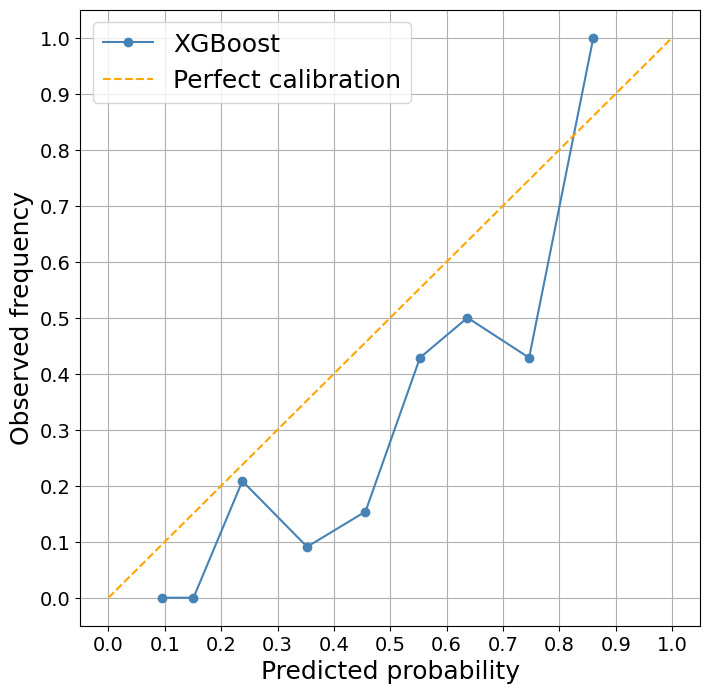

In [29]:
tick_size = 14
label_size = 18
legend_size = 18
text_size = 18

prob_true, prob_pred = calibration_curve(
    y_test_true,
    y_test_proba[:,1],
    n_bins=10,
    strategy="uniform"
)

plt.subplots(1, figsize=(8,8))

plt.plot(prob_pred, prob_true, marker="o", color = 'steelblue', label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--", color = 'orange', label="Perfect calibration")

plt.xlabel("Predicted probability", size=label_size)
plt.ylabel("Observed frequency", size=label_size)
plt.yticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.xticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.legend(prop={'size': legend_size})
plt.grid(True)
plt.show()

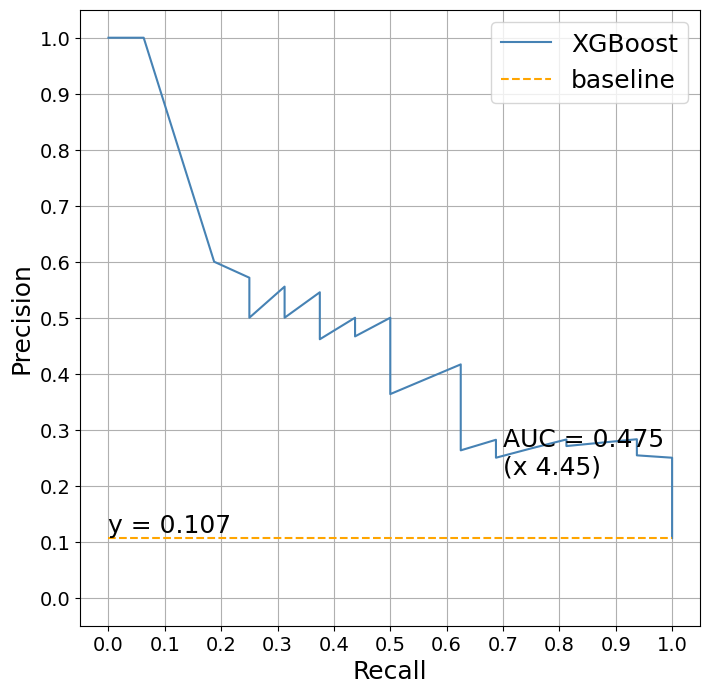

(0.625, 0.42, 0.5, 0.47)

In [31]:
plot_pr_curve(df_test, score_col = 'risk_score',target_col = 'target', model_name='XGBoost', plot_fbeta=False, beta = 1)

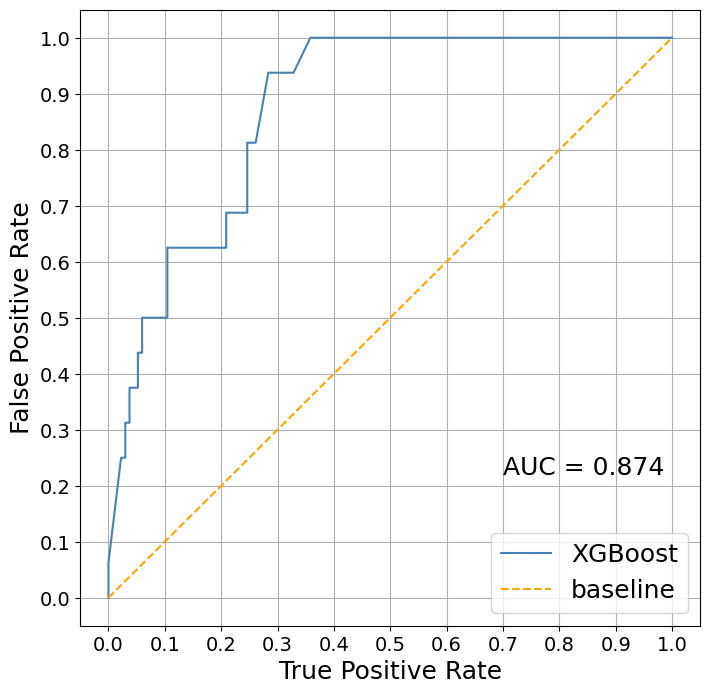

(0.2836, 0.9375, 0.8195, 0.2361)

In [32]:
plot_roc_curve(df_test, score_col = 'risk_score',target_col = 'target', model_name='XGBoost')

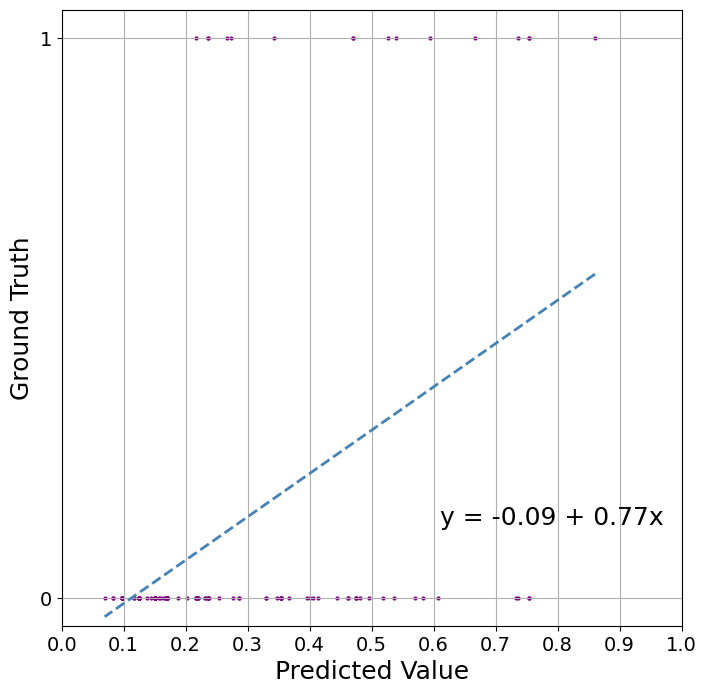

(-0.0875965830556744, 0.7736559017207257)

In [35]:
plot_probability_curve(df_test,score_column = 'risk_score', target_col = 'target', marker_size=4, x_label = 'Predicted Value', marker_shape='o')